# 1D-CNN 다중 출력 피부층 깊이 예측 v2

**입력**: 2050샘플 ADC 신호 (18.5~39.0μs) → 정규화 [-1, +1]  
**출력**:
- `dermis_mm` — 진피 깊이 (항상 예측)
- `fascia_mm` — 근막 깊이 (있을 수도 없을 수도)
- `bone_mm` — 뼈 깊이 (있을 수도 없을 수도)

**구조**: 공유 인코더 + 회귀 헤드(3값) + 분류 헤드(존재 여부 2값)  
**손실**: 마스킹된 MAE(회귀) + BCE(존재 분류)  
**평가**: LOO-CV (환자별 검증)

## 0. 환경 설정

In [1]:
import re, json, itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.font_manager as fm
from IPython.display import clear_output, display

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

# 한글 폰트
_ko_candidates = [f.fname for f in fm.fontManager.ttflist if 'Noto Sans CJK' in f.name]
if _ko_candidates:
    fm.fontManager.addfont(_ko_candidates[0])
    _ko_name = fm.FontProperties(fname=_ko_candidates[0]).get_name()
    plt.rcParams['font.family']     = 'sans-serif'
    plt.rcParams['font.sans-serif'] = [_ko_name, 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

ROOT       = Path('.').resolve()
USDATA     = ROOT / 'usdata' / 'data'
RESULT_DIR = ROOT / 'results'
RESULT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TRIM_START, TRIM_COUNT = 1850, 2050
SOUND_SPEED = 1540.0

FILENAME_RE = re.compile(
    r'^(?P<name>.+)_(?P<date>\d{8})_(?P<time>\d{6})_'
    r'\((?P<pos_num>\d+)\)(?P<position>.+?)_(?P<gender>[MF])\.csv$'
)

print(f'Device : {DEVICE}')
print(f'USDATA : {USDATA}')
print(f'Results: {RESULT_DIR}')

Device : cpu
USDATA : /home/dmjang/work/ultrasound_analysis/usdata/data
Results: /home/dmjang/work/ultrasound_analysis/results


## 1. 데이터 로드

In [2]:
def load_adc(path):
    adc = []
    with open(path, encoding='utf-8', errors='replace') as fh:
        for line in fh:
            line = line.strip()
            if not line: continue
            try:
                v = int(line)
                if 0 <= v <= 255: adc.append(v)
            except ValueError: pass
    adc = np.array(adc, dtype=np.float32)
    if len(adc) > TRIM_COUNT:
        end = TRIM_START + TRIM_COUNT
        adc = adc[TRIM_START:end] if len(adc) >= end else adc[TRIM_START:]
    if len(adc) < TRIM_COUNT:
        adc = np.pad(adc, (0, TRIM_COUNT - len(adc)))
    return adc[:TRIM_COUNT]


def load_label(csv_path):
    """JSON에서 진피/근막/뼈 깊이 로드.
    Returns: (dermis_mm, fascia_mm_or_None, bone_mm_or_None)
             진피가 없으면 None 반환 (샘플 제외).
    """
    json_path = csv_path.with_name(csv_path.stem + '_positions.json')
    if not json_path.exists(): return None
    with open(json_path, encoding='utf-8') as fh:
        data = json.load(fh)

    dermis_mm = fascia_mm = bone_mm = None

    for pos in data.get('positions', []):
        name = pos.get('position_name', '')
        mm   = pos.get('thickness_mm')
        if name in ('피하지방시작', 'Dermis') and mm is not None:
            dermis_mm = float(mm)
        elif name == 'Fascia' and mm is not None:
            fascia_mm = float(mm)

    be = data.get('bone_echo')
    if be and be.get('depth_mm') is not None:
        bone_mm = float(be['depth_mm'])

    if dermis_mm is None: return None
    return dermis_mm, fascia_mm, bone_mm


def build_dataset():
    rows = []
    for csv_path in sorted(USDATA.rglob('*.csv')):
        if '_positions' in csv_path.name: continue
        # 펄서 디렉토리 제외
        if '펄서' in str(csv_path): continue
        m = FILENAME_RE.match(csv_path.name)
        if not m: continue
        # 허공 측정 제외
        if int(m.group('pos_num')) == 0: continue
        label = load_label(csv_path)
        if label is None: continue
        dermis_mm, fascia_mm, bone_mm = label
        adc = load_adc(csv_path)
        rows.append({
            'patient':  m.group('name'),
            'position': m.group('position'),
            'pos_num':  int(m.group('pos_num')),
            'adc':      adc,
            'dermis':   dermis_mm,
            'fascia':   fascia_mm,   # None 허용
            'bone':     bone_mm,     # None 허용
        })
    return rows


ALL_ROWS = build_dataset()
patients = sorted({r['patient'] for r in ALL_ROWS})

n_fascia = sum(1 for r in ALL_ROWS if r['fascia'] is not None)
n_bone   = sum(1 for r in ALL_ROWS if r['bone']   is not None)
print(f'총 샘플  : {len(ALL_ROWS)}개  /  환자: {len(patients)}명')
print(f'근막 있음: {n_fascia}개 ({100*n_fascia/len(ALL_ROWS):.1f}%)')
print(f'뼈   있음: {n_bone}개 ({100*n_bone/len(ALL_ROWS):.1f}%)')
print(f'환자 목록: {patients}')

# 라벨 분포 (d_vals/f_vals/b_vals — F는 torch.nn.functional 예약)
d_vals = [r['dermis'] for r in ALL_ROWS]
f_vals = [r['fascia'] for r in ALL_ROWS if r['fascia'] is not None]
b_vals = [r['bone']   for r in ALL_ROWS if r['bone']   is not None]
print(f'\n진피 평균: {np.mean(d_vals):.3f} ± {np.std(d_vals):.3f} mm  [{np.min(d_vals):.2f}~{np.max(d_vals):.2f}]')
print(f'근막 평균: {np.mean(f_vals):.3f} ± {np.std(f_vals):.3f} mm  [{np.min(f_vals):.2f}~{np.max(f_vals):.2f}]')
print(f'뼈   평균: {np.mean(b_vals):.3f} ± {np.std(b_vals):.3f} mm  [{np.min(b_vals):.2f}~{np.max(b_vals):.2f}]')

총 샘플  : 1200개  /  환자: 20명
근막 있음: 806개 (67.2%)
뼈   있음: 1082개 (90.2%)
환자 목록: ['권영남', '김선일', '김수현', '김희락', '박성수', '박인석', '박인식', '서영수', '송용범', '송인광', '양창식', '오광', '윤아영', '장동만', '정병훈', '조세일', '조현수', '한승현', '홍충만', '황인홍']

진피 평균: 1.781 ± 0.117 mm  [1.54~2.05]
근막 평균: 3.969 ± 0.064 mm  [3.76~4.13]
뼈   평균: 5.524 ± 1.120 mm  [3.08~8.59]


## 2. Dataset / Model 정의

In [3]:
class UltrasoundDataset(Dataset):
    def __init__(self, rows):
        x = np.stack([(r['adc'] - 128.0) / 128.0 for r in rows], axis=0)
        self.x = torch.tensor(x, dtype=torch.float32).unsqueeze(1)  # (N,1,2050)

        # 회귀 목표: [dermis, fascia(없으면0), bone(없으면0)]
        y_reg = np.array([
            [r['dermis'],
             r['fascia'] if r['fascia'] is not None else 0.0,
             r['bone']   if r['bone']   is not None else 0.0]
            for r in rows
        ], dtype=np.float32)

        # 분류 목표: [has_fascia, has_bone] (0 or 1)
        y_cls = np.array([
            [1.0 if r['fascia'] is not None else 0.0,
             1.0 if r['bone']   is not None else 0.0]
            for r in rows
        ], dtype=np.float32)

        self.y_reg = torch.tensor(y_reg, dtype=torch.float32)
        self.y_cls = torch.tensor(y_cls, dtype=torch.float32)

    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y_reg[i], self.y_cls[i]


class SkinCNN(nn.Module):
    """다중 출력 1D-CNN (NPU INT8 양자화 고려)

    출력:
        reg (B, 3): [dermis_mm, fascia_mm, bone_mm]
        cls (B, 2): [has_fascia_logit, has_bone_logit]  ← sigmoid 후 0.5 기준 판단
    """
    def __init__(self, n_filters=16, dropout=0.3):
        super().__init__()
        f = n_filters
        self.encoder = nn.Sequential(
            nn.Conv1d(1,   f,   kernel_size=15, stride=2, padding=7),  nn.BatchNorm1d(f),   nn.ReLU(),
            nn.Conv1d(f,   f*2, kernel_size=7,  stride=2, padding=3),  nn.BatchNorm1d(f*2), nn.ReLU(),
            nn.Conv1d(f*2, f*4, kernel_size=5,  stride=2, padding=2),  nn.BatchNorm1d(f*4), nn.ReLU(),
            nn.Conv1d(f*4, f*4, kernel_size=5,  stride=2, padding=2),  nn.BatchNorm1d(f*4), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.shared = nn.Sequential(
            nn.Flatten(),
            nn.Linear(f*4, f*2), nn.ReLU(), nn.Dropout(dropout),
        )
        self.reg_head = nn.Linear(f*2, 3)   # [dermis, fascia, bone]
        self.cls_head = nn.Linear(f*2, 2)   # [has_fascia, has_bone] logits

    def forward(self, x):
        feat = self.shared(self.encoder(x))
        return self.reg_head(feat), self.cls_head(feat)

    def predict(self, x, cls_threshold=0.5):
        """추론 전용: 분류 결과를 반영해 없는 항목은 None으로 반환.
        Returns: (dermis_mm, fascia_mm_or_None, bone_mm_or_None)
        """
        self.eval()
        with torch.no_grad():
            reg, cls = self.forward(x)
            prob = torch.sigmoid(cls)
            dermis = reg[:, 0]
            fascia = torch.where(prob[:, 0] >= cls_threshold, reg[:, 1],
                                 torch.full_like(reg[:, 1], float('nan')))
            bone   = torch.where(prob[:, 1] >= cls_threshold, reg[:, 2],
                                 torch.full_like(reg[:, 2], float('nan')))
        return dermis, fascia, bone

    def n_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


for f in [16, 32]:
    m = SkinCNN(n_filters=f)
    print(f'n_filters={f:2d} → 파라미터 {m.n_params():,}개')

# 입출력 형태 확인
_tmp = torch.randn(2, 1, TRIM_COUNT)
_reg, _cls = SkinCNN()(_tmp)
print(f'입력 {tuple(_tmp.shape)}  →  reg {tuple(_reg.shape)}  cls {tuple(_cls.shape)}')

n_filters=16 → 파라미터 37,317개
n_filters=32 → 파라미터 147,333개
입력 (2, 1, 2050)  →  reg (2, 3)  cls (2, 2)


## 3. 손실 함수

In [4]:
def multitask_loss(pred_reg, pred_cls, y_reg, y_cls, λ_cls=0.5):
    """마스킹된 MAE(회귀) + BCE(존재 분류) 혼합 손실.

    Args:
        pred_reg (B,3): 예측 [dermis, fascia, bone]
        pred_cls (B,2): logits [has_fascia, has_bone]
        y_reg    (B,3): 실제 값 (없으면 0)
        y_cls    (B,2): 실제 존재 여부 (0 or 1)
        λ_cls        : 분류 손실 가중치
    Returns:
        total, l_dermis, l_fascia, l_bone, l_cls
    """
    fascia_mask = y_cls[:, 0] > 0.5
    bone_mask   = y_cls[:, 1] > 0.5

    l_dermis = F.l1_loss(pred_reg[:, 0], y_reg[:, 0])

    l_fascia = (F.l1_loss(pred_reg[fascia_mask, 1], y_reg[fascia_mask, 1])
                if fascia_mask.any() else pred_reg.new_tensor(0.0))

    l_bone = (F.l1_loss(pred_reg[bone_mask, 2], y_reg[bone_mask, 2])
              if bone_mask.any() else pred_reg.new_tensor(0.0))

    # BCE: pos_weight로 불균형 보정 (근막 있음 67%, 뼈 있음 90%)
    n_pos_f = fascia_mask.sum().float()
    n_neg_f = (~fascia_mask).sum().float()
    n_pos_b = bone_mask.sum().float()
    n_neg_b = (~bone_mask).sum().float()
    w_f = (n_neg_f / n_pos_f.clamp(min=1.0)).clamp(max=10.0)
    w_b = (n_neg_b / n_pos_b.clamp(min=1.0)).clamp(max=10.0)
    l_cls = (F.binary_cross_entropy_with_logits(pred_cls[:, 0], y_cls[:, 0], pos_weight=w_f) +
             F.binary_cross_entropy_with_logits(pred_cls[:, 1], y_cls[:, 1], pos_weight=w_b))

    total = l_dermis + l_fascia + l_bone + λ_cls * l_cls
    return total, l_dermis, l_fascia, l_bone, l_cls


print('손실 함수 정의 완료')

손실 함수 정의 완료


## 4. [설정] 하이퍼파라미터

In [5]:
HP = dict(
    lr         = 1e-3,
    batch      = 32,
    n_filters  = 16,
    dropout    = 0.2,
    epochs     = 150,
    patience   = 20,
    final_ep   = 200,
    lambda_cls = 0.5,   # 분류 손실 가중치
)

print('현재 하이퍼파라미터:')
for k, v in HP.items(): print(f'  {k:<14s} = {v}')

현재 하이퍼파라미터:
  lr             = 0.001
  batch          = 32
  n_filters      = 16
  dropout        = 0.2
  epochs         = 150
  patience       = 20
  final_ep       = 200
  lambda_cls     = 0.5


## 5. 학습 함수

In [6]:
def train_epoch(model, loader, optimizer, λ_cls):
    model.train()
    total = 0
    for x, y_reg, y_cls in loader:
        x, y_reg, y_cls = x.to(DEVICE), y_reg.to(DEVICE), y_cls.to(DEVICE)
        optimizer.zero_grad()
        pred_reg, pred_cls = model(x)
        loss, *_ = multitask_loss(pred_reg, pred_cls, y_reg, y_cls, λ_cls)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(x)
    return total / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, λ_cls=0.5, cls_threshold=0.5):
    model.eval()
    total_loss = 0
    all_reg, all_cls_prob, all_y_reg, all_y_cls = [], [], [], []

    for x, y_reg, y_cls in loader:
        x, y_reg, y_cls = x.to(DEVICE), y_reg.to(DEVICE), y_cls.to(DEVICE)
        pred_reg, pred_cls = model(x)
        loss, *_ = multitask_loss(pred_reg, pred_cls, y_reg, y_cls, λ_cls)
        total_loss += loss.item() * len(x)
        all_reg.append(pred_reg.cpu().numpy())
        all_cls_prob.append(torch.sigmoid(pred_cls).cpu().numpy())
        all_y_reg.append(y_reg.cpu().numpy())
        all_y_cls.append(y_cls.cpu().numpy())

    pred_reg  = np.concatenate(all_reg,       axis=0)
    pred_prob = np.concatenate(all_cls_prob,   axis=0)
    y_reg     = np.concatenate(all_y_reg,      axis=0)
    y_cls     = np.concatenate(all_y_cls,      axis=0)

    fascia_mask = y_cls[:, 0] > 0.5
    bone_mask   = y_cls[:, 1] > 0.5

    mae_d = float(np.mean(np.abs(pred_reg[:, 0] - y_reg[:, 0])))
    mae_f = float(np.mean(np.abs(pred_reg[fascia_mask, 1] - y_reg[fascia_mask, 1]))) \
            if fascia_mask.any() else float('nan')
    mae_b = float(np.mean(np.abs(pred_reg[bone_mask, 2] - y_reg[bone_mask, 2]))) \
            if bone_mask.any() else float('nan')

    # 분류 정확도
    pred_has_f = pred_prob[:, 0] >= cls_threshold
    pred_has_b = pred_prob[:, 1] >= cls_threshold
    acc_f = float(np.mean(pred_has_f == (fascia_mask))) if len(y_cls) > 0 else float('nan')
    acc_b = float(np.mean(pred_has_b == (bone_mask)))   if len(y_cls) > 0 else float('nan')

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, mae_d, mae_f, mae_b, acc_f, acc_b, pred_reg, pred_prob, y_reg, y_cls


def train_model(train_rows, val_rows, hp, live_plot=False, title=''):
    train_ld = DataLoader(UltrasoundDataset(train_rows), batch_size=hp['batch'],
                          shuffle=True, drop_last=len(train_rows) > hp['batch'])
    val_ld   = DataLoader(UltrasoundDataset(val_rows),   batch_size=hp['batch'])

    model     = SkinCNN(n_filters=hp['n_filters'], dropout=hp['dropout']).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=hp['lr'], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=hp['epochs'])
    λ_cls     = hp.get('lambda_cls', 0.5)

    best_val, best_state, no_imp = float('inf'), None, 0
    hist = {'tr': [], 'val': [], 'mae_d': [], 'mae_f': [], 'mae_b': [], 'acc_f': [], 'acc_b': []}

    if live_plot:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(title or '학습 진행')

    pbar = tqdm(range(1, hp['epochs'] + 1), desc=title or '학습', leave=True)
    for ep in pbar:
        tr  = train_epoch(model, train_ld, optimizer, λ_cls)
        val, mae_d, mae_f, mae_b, acc_f, acc_b, *_ = eval_epoch(model, val_ld, λ_cls)
        scheduler.step()

        hist['tr'].append(tr);     hist['val'].append(val)
        hist['mae_d'].append(mae_d)
        hist['mae_f'].append(mae_f if not np.isnan(mae_f) else 0.0)
        hist['mae_b'].append(mae_b if not np.isnan(mae_b) else 0.0)
        hist['acc_f'].append(acc_f); hist['acc_b'].append(acc_b)

        if val < best_val:
            best_val   = val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1

        f_str = f'{mae_f:.3f}' if not np.isnan(mae_f) else 'N/A'
        b_str = f'{mae_b:.3f}' if not np.isnan(mae_b) else 'N/A'
        pbar.set_postfix(tr=f'{tr:.4f}', val=f'{val:.4f}',
                         D=f'{mae_d:.3f}', F=f_str, B=b_str,
                         afF=f'{acc_f:.2f}', afB=f'{acc_b:.2f}',
                         pat=f'{no_imp}/{hp["patience"]}')

        if live_plot and ep % 10 == 0:
            clear_output(wait=True)
            display(fig)
            ep_x = range(1, len(hist['tr']) + 1)
            axes[0].cla()
            axes[0].plot(ep_x, hist['tr'],  label='Train', color='steelblue')
            axes[0].plot(ep_x, hist['val'], label='Val',   color='tomato')
            axes[0].set_title(f'Loss (best={best_val:.4f})'); axes[0].legend(); axes[0].grid(alpha=0.3)

            axes[1].cla()
            axes[1].plot(ep_x, hist['mae_d'], label='Dermis', color='green')
            axes[1].plot(ep_x, hist['mae_f'], label='Fascia', color='purple')
            axes[1].plot(ep_x, hist['mae_b'], label='Bone',   color='brown')
            axes[1].axhline(0.3, color='red', linestyle='--', linewidth=1)
            axes[1].set_title('MAE (mm)'); axes[1].legend(); axes[1].grid(alpha=0.3)

            axes[2].cla()
            axes[2].plot(ep_x, hist['acc_f'], label='Fascia 존재 정확도', color='purple')
            axes[2].plot(ep_x, hist['acc_b'], label='뼈 존재 정확도',    color='brown')
            axes[2].set_ylim(0, 1.05)
            axes[2].set_title('분류 정확도'); axes[2].legend(); axes[2].grid(alpha=0.3)
            fig.tight_layout()

        if no_imp >= hp['patience']:
            pbar.set_description(f'{title or "학습"} 조기종료 ep={ep}')
            break

    if live_plot:
        clear_output(wait=True)
        display(fig)
        plt.close(fig)

    model.load_state_dict(best_state)
    return model, hist


print('학습 함수 정의 완료')

학습 함수 정의 완료


## 6. 단일 학습 (실시간 플롯)

마지막 환자를 검증셋으로 고정하여 빠른 확인

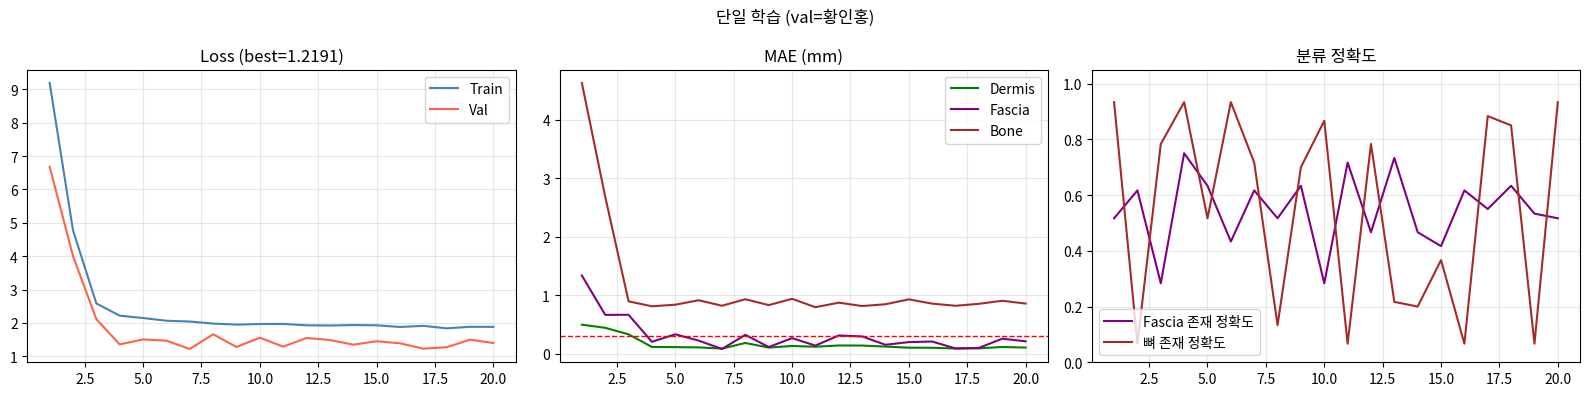


=== 단일 학습 검증 결과 ===
진피  MAE : 0.0842 mm  ✓
근막  MAE : 0.0775 mm  ✓  (있는 샘플만)
뼈    MAE : 0.8170 mm  ✗  (있는 샘플만)
근막 분류 정확도: 61.7%
뼈   분류 정확도: 71.7%


In [7]:
val_pat    = patients[-1]
train_rows = [r for r in ALL_ROWS if r['patient'] != val_pat]
val_rows   = [r for r in ALL_ROWS if r['patient'] == val_pat]

n_f_val = sum(1 for r in val_rows if r['fascia'] is not None)
n_b_val = sum(1 for r in val_rows if r['bone']   is not None)
print(f'Train: {len(train_rows)}개  /  Val: {len(val_rows)}개 (환자: {val_pat})')
print(f'Val  — 근막 있음: {n_f_val}개  뼈 있음: {n_b_val}개')
print(f'모델 파라미터: {SkinCNN(HP["n_filters"], HP["dropout"]).n_params():,}개\n')

model_single, hist_single = train_model(
    train_rows, val_rows, HP,
    live_plot=True,
    title=f'단일 학습 (val={val_pat})'
)

_, mae_d, mae_f, mae_b, acc_f, acc_b, *_ = eval_epoch(
    model_single,
    DataLoader(UltrasoundDataset(val_rows), batch_size=32),
    HP['lambda_cls']
)
print(f'\n=== 단일 학습 검증 결과 ===')
print(f'진피  MAE : {mae_d:.4f} mm  {"✓" if mae_d < 0.3 else "✗"}')
print(f'근막  MAE : {mae_f:.4f} mm  {"✓" if mae_f < 0.3 else "✗"}  (있는 샘플만)')
print(f'뼈    MAE : {mae_b:.4f} mm  {"✓" if mae_b < 0.3 else "✗"}  (있는 샘플만)')
print(f'근막 분류 정확도: {acc_f*100:.1f}%')
print(f'뼈   분류 정확도: {acc_b*100:.1f}%')

## 7. LOO-CV

In [8]:
def run_loo_cv(all_rows, hp, quick=False):
    patients = sorted({r['patient'] for r in all_rows})
    cv_hp    = {**hp, 'epochs': 80 if quick else hp['epochs']}
    records  = []

    print(f'LOO-CV 시작: {len(patients)}명  (epochs={cv_hp["epochs"]})')
    print('-' * 78)

    for i, pat in enumerate(patients):
        tr  = [r for r in all_rows if r['patient'] != pat]
        val = [r for r in all_rows if r['patient'] == pat]

        model, _ = train_model(tr, val, cv_hp, live_plot=False,
                               title=f'[{i+1:2d}/{len(patients)}] {pat}')

        _, mae_d, mae_f, mae_b, acc_f, acc_b, pred_reg, pred_prob, y_reg, y_cls = eval_epoch(
            model,
            DataLoader(UltrasoundDataset(val), batch_size=32),
            cv_hp['lambda_cls']
        )
        f_str = f'{mae_f:.3f}' if not np.isnan(mae_f) else '  N/A'
        b_str = f'{mae_b:.3f}' if not np.isnan(mae_b) else '  N/A'
        print(f'  [{i+1:2d}/{len(patients)}] {pat:<10s}  '
              f'D={mae_d:.3f}  F={f_str}  B={b_str}  '
              f'accF={acc_f*100:.0f}%  accB={acc_b*100:.0f}%  (n={len(val)})')
        records.append({
            'patient':   pat,
            'n_test':    len(val),
            'mae_dermis': mae_d,
            'mae_fascia': mae_f,
            'mae_bone':   mae_b,
            'acc_fascia': acc_f,
            'acc_bone':   acc_b,
            'pred_reg':   pred_reg,
            'pred_prob':  pred_prob,
            'y_reg':      y_reg,
            'y_cls':      y_cls,
        })

    df = pd.DataFrame(records)
    print('-' * 78)
    for col, label in [('mae_dermis','진피 MAE'), ('mae_fascia','근막 MAE'), ('mae_bone','뼈   MAE')]:
        vals = df[col].dropna()
        print(f'  평균 {label}: {vals.mean():.3f} ± {vals.std():.3f} mm')
    print(f'  평균 근막 분류 정확도: {df["acc_fascia"].mean()*100:.1f}%')
    print(f'  평균 뼈   분류 정확도: {df["acc_bone"].mean()*100:.1f}%')
    return df


CV_DF = run_loo_cv(ALL_ROWS, HP, quick=True)

LOO-CV 시작: 20명  (epochs=80)
------------------------------------------------------------------------------


[ 1/20] 권영남:   0%|          | 0/80 [00:00<?, ?it/s]

  [ 1/20] 권영남         D=0.093  F=0.090  B=0.960  accF=55%  accB=10%  (n=60)


[ 2/20] 김선일:   0%|          | 0/80 [00:00<?, ?it/s]

  [ 2/20] 김선일         D=0.092  F=0.093  B=0.626  accF=57%  accB=42%  (n=60)


...

  [18/20] 한승현         D=0.104  F=0.095  B=0.763  accF=77%  accB=53%  (n=60)


[19/20] 홍충만:   0%|          | 0/80 [00:00<?, ?it/s]

  [19/20] 홍충만         D=0.110  F=0.080  B=0.597  accF=60%  accB=73%  (n=60)


[20/20] 황인홍:   0%|          | 0/80 [00:00<?, ?it/s]

  [20/20] 황인홍         D=0.089  F=0.111  B=0.826  accF=43%  accB=57%  (n=60)
------------------------------------------------------------------------------
  평균 진피 MAE: 0.099 ± 0.009 mm
  평균 근막 MAE: 0.089 ± 0.017 mm
  평균 뼈   MAE: 0.824 ± 0.121 mm
  평균 근막 분류 정확도: 62.4%
  평균 뼈   분류 정확도: 57.1%


## 8. 결과 저장 / 시각화

저장: /home/dmjang/work/ultrasound_analysis/results/cnn_v2_loo_cv.png


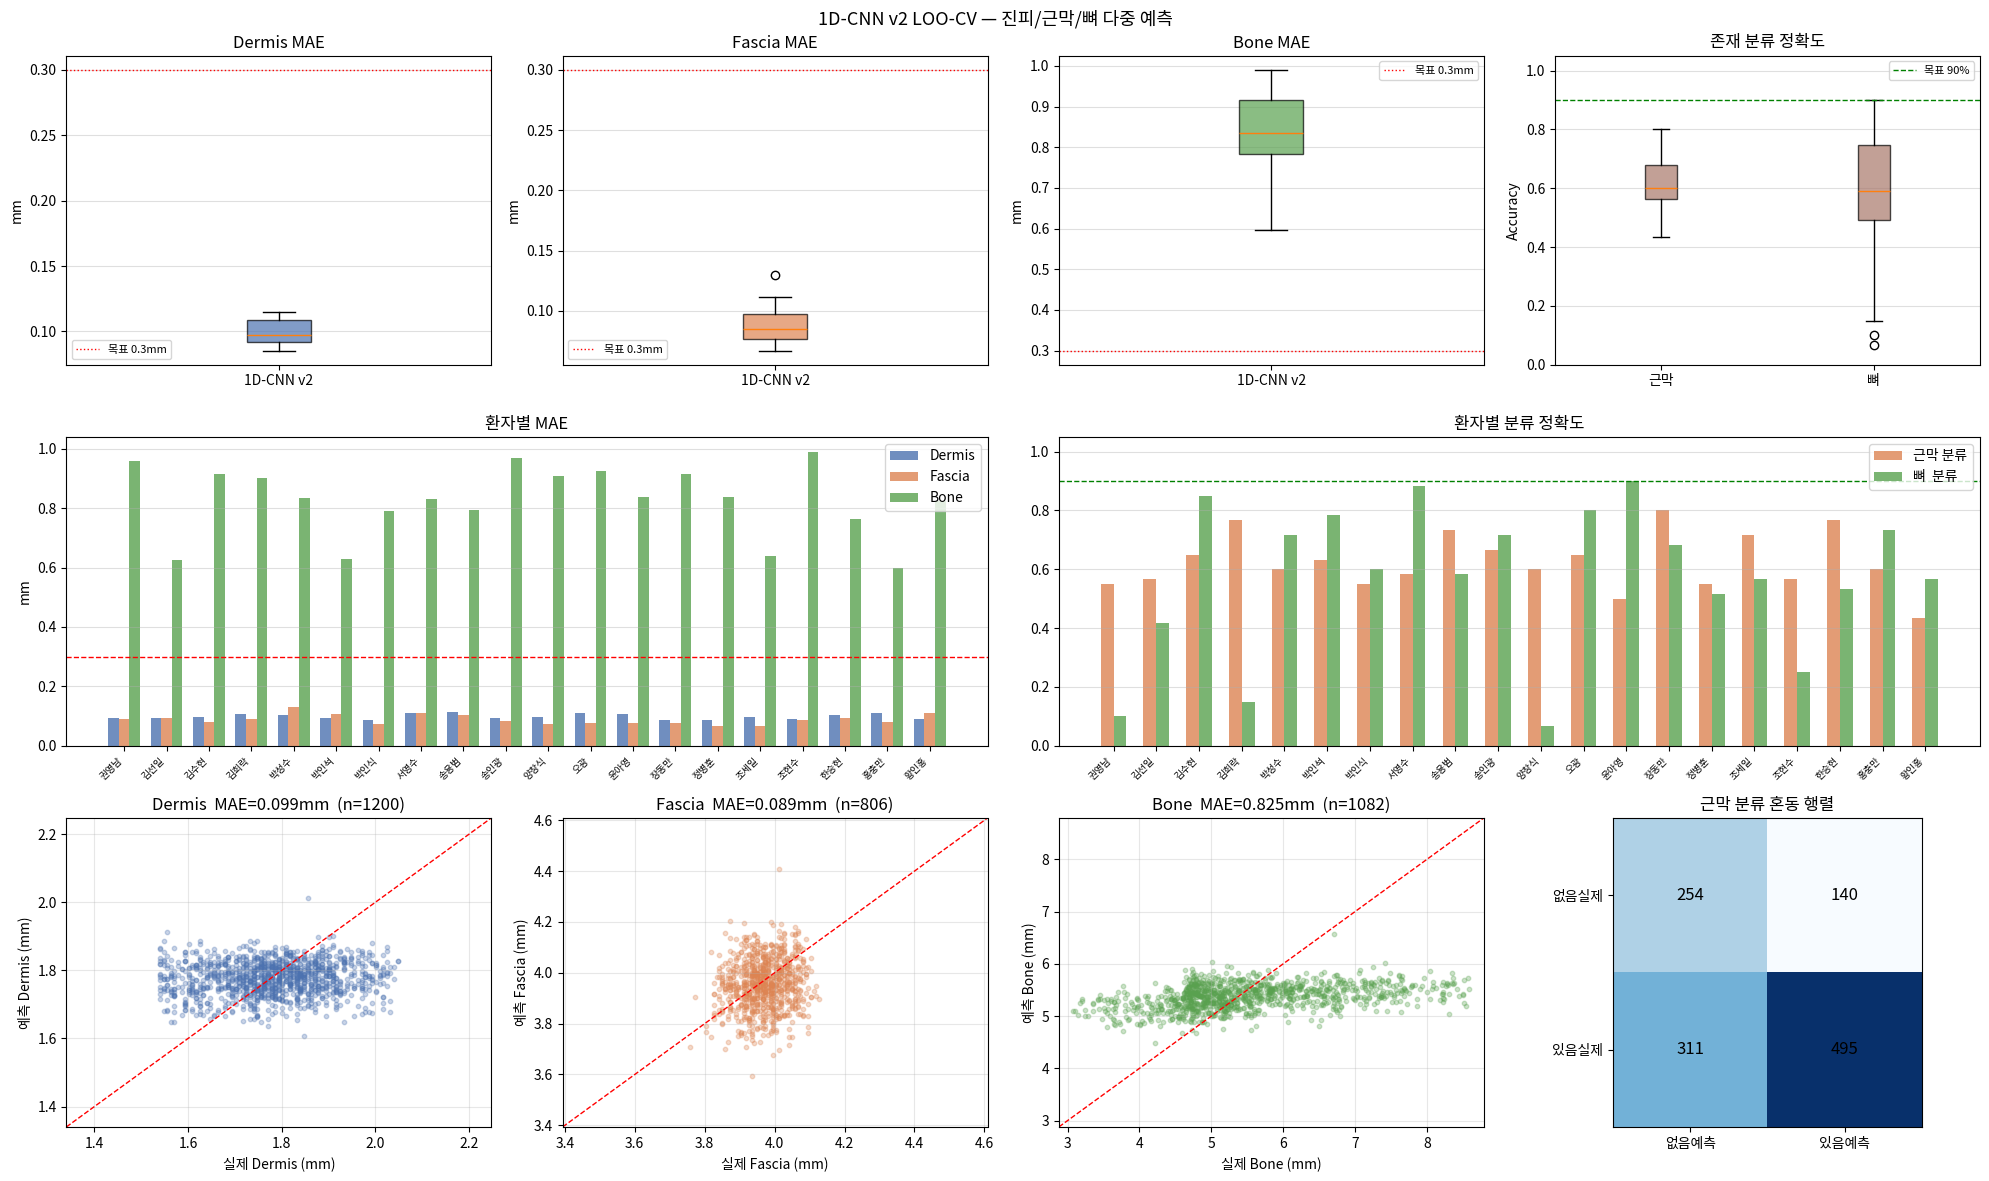

In [9]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('1D-CNN v2 LOO-CV — 진피/근막/뼈 다중 예측', fontsize=13)
gs  = gridspec.GridSpec(3, 4, figure=fig)

# ① MAE 박스플롯
for col_i, (key, label, color) in enumerate([
    ('mae_dermis', 'Dermis', '#4c72b0'),
    ('mae_fascia', 'Fascia', '#dd8452'),
    ('mae_bone',   'Bone',   '#59a14f'),
]):
    ax = fig.add_subplot(gs[0, col_i])
    vals = CV_DF[key].dropna().values
    ax.boxplot([vals], tick_labels=['1D-CNN v2'], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.axhline(0.3, color='red', linestyle=':', linewidth=1, label='목표 0.3mm')
    ax.set_title(f'{label} MAE'); ax.set_ylabel('mm'); ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.4)

# ② 분류 정확도 박스플롯
ax = fig.add_subplot(gs[0, 3])
ax.boxplot([CV_DF['acc_fascia'].values, CV_DF['acc_bone'].values],
           tick_labels=['근막', '뼈'], patch_artist=True,
           boxprops=dict(facecolor='#a8786a', alpha=0.7))
ax.axhline(0.9, color='green', linestyle='--', linewidth=1, label='목표 90%')
ax.set_title('존재 분류 정확도'); ax.set_ylabel('Accuracy'); ax.legend(fontsize=8)
ax.set_ylim(0, 1.05); ax.grid(axis='y', alpha=0.4)

# ③ 환자별 MAE 막대
ax = fig.add_subplot(gs[1, :2])
x = np.arange(len(CV_DF))
ax.bar(x - 0.25, CV_DF['mae_dermis'], 0.25, label='Dermis', color='#4c72b0', alpha=0.8)
ax.bar(x,        CV_DF['mae_fascia'], 0.25, label='Fascia', color='#dd8452', alpha=0.8)
ax.bar(x + 0.25, CV_DF['mae_bone'],   0.25, label='Bone',   color='#59a14f', alpha=0.8)
ax.axhline(0.3, color='red', linestyle='--', linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(CV_DF['patient'], rotation=45, ha='right', fontsize=7)
ax.set_title('환자별 MAE'); ax.set_ylabel('mm'); ax.legend(); ax.grid(axis='y', alpha=0.4)

# ④ 환자별 분류 정확도
ax = fig.add_subplot(gs[1, 2:])
ax.bar(x - 0.15, CV_DF['acc_fascia'], 0.3, label='근막 분류', color='#dd8452', alpha=0.8)
ax.bar(x + 0.15, CV_DF['acc_bone'],   0.3, label='뼈  분류',  color='#59a14f', alpha=0.8)
ax.axhline(0.9, color='green', linestyle='--', linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(CV_DF['patient'], rotation=45, ha='right', fontsize=7)
ax.set_title('환자별 분류 정확도'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis='y', alpha=0.4)

# ⑤⑥⑦ 예측 vs 실제 산점도
all_pred_reg  = np.concatenate([r['pred_reg']  for r in CV_DF.to_dict('records')])
all_pred_prob = np.concatenate([r['pred_prob'] for r in CV_DF.to_dict('records')])
all_y_reg     = np.concatenate([r['y_reg']     for r in CV_DF.to_dict('records')])
all_y_cls     = np.concatenate([r['y_cls']     for r in CV_DF.to_dict('records')])

for col_i, (idx, label, color, mask_col) in enumerate([
    (0, 'Dermis', '#4c72b0', None),
    (1, 'Fascia', '#dd8452', 0),
    (2, 'Bone',   '#59a14f', 1),
]):
    ax = fig.add_subplot(gs[2, col_i])
    if mask_col is not None:
        mask = all_y_cls[:, mask_col] > 0.5
        pred = all_pred_reg[mask, idx]
        true = all_y_reg[mask, idx]
    else:
        pred = all_pred_reg[:, idx]
        true = all_y_reg[:, idx]
    if len(pred) == 0:
        ax.text(0.5, 0.5, '데이터 없음', ha='center', transform=ax.transAxes)
        continue
    ax.scatter(true, pred, alpha=0.3, s=10, color=color)
    lim = [min(true.min(), pred.min()) - 0.2, max(true.max(), pred.max()) + 0.2]
    ax.plot(lim, lim, 'r--', linewidth=1)
    mae = float(np.mean(np.abs(pred - true)))
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel(f'실제 {label} (mm)'); ax.set_ylabel(f'예측 {label} (mm)')
    ax.set_title(f'{label}  MAE={mae:.3f}mm  (n={len(pred)})')
    ax.grid(alpha=0.3)

# ⑧ 분류 혼동 행렬 (근막)
ax = fig.add_subplot(gs[2, 3])
pred_has_f = all_pred_prob[:, 0] >= 0.5
true_has_f = all_y_cls[:, 0] > 0.5
from sklearn.metrics import confusion_matrix
try:
    cm_f = confusion_matrix(true_has_f, pred_has_f)
    ax.imshow(cm_f, cmap='Blues')
    for ri in range(2):
        for ci in range(2):
            ax.text(ci, ri, str(cm_f[ri, ci]), ha='center', va='center', fontsize=12)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['없음예측','있음예측']); ax.set_yticklabels(['없음실제','있음실제'])
    ax.set_title('근막 분류 혼동 행렬')
except Exception:
    ax.text(0.5, 0.5, 'sklearn 없음', ha='center', transform=ax.transAxes)

fig.tight_layout()
out = RESULT_DIR / 'cnn_v2_loo_cv.png'
fig.savefig(out, dpi=150)
print(f'저장: {out}')
plt.show()

## 9. 최종 모델 저장

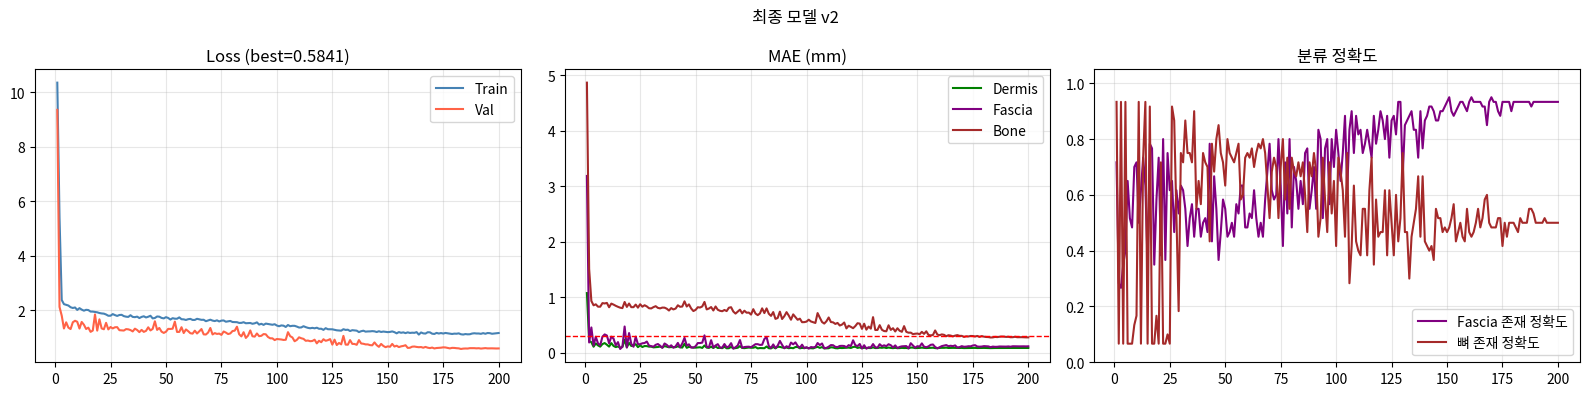


모델 저장: /home/dmjang/work/ultrasound_analysis/results/best_1dcnn_v2.pth

=== LOO-CV 최종 결과 ===
진피  MAE : 0.099 ± 0.009 mm
근막  MAE : 0.089 ± 0.017 mm
뼈    MAE : 0.824 ± 0.121 mm
근막 분류 : 62.4%
뼈   분류 : 57.1%


In [10]:
print('최종 모델 학습 중 (전체 데이터)...')
final_hp = {**HP, 'epochs': HP['final_ep'], 'patience': 30}

final_model, final_hist = train_model(
    ALL_ROWS,
    [r for r in ALL_ROWS if r['patient'] == patients[-1]],
    final_hp,
    live_plot=True,
    title='최종 모델 v2'
)

model_path = RESULT_DIR / 'best_1dcnn_v2.pth'
torch.save({
    'model_state':     final_model.state_dict(),
    'model_class':     'SkinCNN_v2',
    'hyperparams':     HP,
    'input_size':      TRIM_COUNT,
    'output_reg':      ['dermis_mm', 'fascia_mm', 'bone_mm'],
    'output_cls':      ['has_fascia', 'has_bone'],
    'cls_threshold':   0.5,
    'cv_mae_dermis':   float(CV_DF['mae_dermis'].mean()),
    'cv_mae_fascia':   float(CV_DF['mae_fascia'].dropna().mean()),
    'cv_mae_bone':     float(CV_DF['mae_bone'].dropna().mean()),
    'cv_acc_fascia':   float(CV_DF['acc_fascia'].mean()),
    'cv_acc_bone':     float(CV_DF['acc_bone'].mean()),
}, model_path)
print(f'\n모델 저장: {model_path}')

print(f'\n=== LOO-CV 최종 결과 ===')
print(f'진피  MAE : {CV_DF["mae_dermis"].mean():.3f} ± {CV_DF["mae_dermis"].std():.3f} mm')
print(f'근막  MAE : {CV_DF["mae_fascia"].dropna().mean():.3f} ± {CV_DF["mae_fascia"].dropna().std():.3f} mm')
print(f'뼈    MAE : {CV_DF["mae_bone"].dropna().mean():.3f} ± {CV_DF["mae_bone"].dropna().std():.3f} mm')
print(f'근막 분류 : {CV_DF["acc_fascia"].mean()*100:.1f}%')
print(f'뼈   분류 : {CV_DF["acc_bone"].mean()*100:.1f}%')

## 10. 추론 예시

In [11]:
# 샘플 하나 추론 예시
sample = ALL_ROWS[0]
x_t = torch.tensor((sample['adc'] - 128.0) / 128.0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

dermis_pred, fascia_pred, bone_pred = final_model.predict(x_t.to(DEVICE))

import math
print(f"파일   : {sample['patient']} pos={sample['pos_num']} ({sample['position']})")
print(f"\n--- 예측 ---")
print(f"진피  : {dermis_pred[0].item():.3f} mm  (실제: {sample['dermis']:.3f} mm)")
fascia_str = f"{fascia_pred[0].item():.3f} mm" if not math.isnan(fascia_pred[0].item()) else "없음"
bone_str   = f"{bone_pred[0].item():.3f} mm"   if not math.isnan(bone_pred[0].item())   else "없음"
true_f = f"{sample['fascia']:.3f} mm" if sample['fascia'] is not None else "없음"
true_b = f"{sample['bone']:.3f} mm"   if sample['bone']   is not None else "없음"
print(f"근막  : {fascia_str}  (실제: {true_f})")
print(f"뼈    : {bone_str}  (실제: {true_b})")

파일   : 박성수 pos=1 (이마_중)

--- 예측 ---
진피  : 1.792 mm  (실제: 1.686 mm)
근막  : 3.941 mm  (실제: 3.904 mm)
뼈    : 5.494 mm  (실제: 5.613 mm)
